# Diabetes Prediction using Machine Learning
### A Comparative Study of Classification Algorithms on the Pima Indians Diabetes Dataset

**Course:** Machine Learning — Semester Project
**Student:** Ghani (FA22-BSE-099)
**Institution:** COMSATS University Islamabad, Abbottabad Campus
**Date:** July 2026

---
This notebook covers dataset loading, exploratory data analysis (EDA), preprocessing,
training of five classification models, model comparison, and evaluation with
accuracy, precision, recall, F1-score, and confusion matrix — following the
project's required report structure.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42


## 1. Dataset Description

**Source:** Pima Indians Diabetes Dataset (National Institute of Diabetes and Digestive
and Kidney Diseases), obtained via Jason Brownlee's public Machine Learning Mastery
GitHub dataset repository:
`https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv`

**Rows:** 768 female patients (Pima Indian heritage, age 21+)
**Columns:** 8 medical predictor features + 1 binary target variable

| Feature | Meaning |
|---|---|
| Glucose | Plasma glucose concentration (2-hr oral glucose tolerance test) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-Hour serum insulin (mu U/ml) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes likelihood based on family history |
| Age | Age in years |
| **Outcome** | Target: 1 = diabetic, 0 = non-diabetic |

**Note:** The original dataset also includes a `Pregnancies` feature. It has been
excluded from this analysis to keep the model focused on non-reproductive clinical
measurements, so it generalizes more naturally beyond the original all-female sample.


In [2]:
raw_columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
               "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv("pima.csv", header=None, names=raw_columns)
df = df.drop(columns=["Pregnancies"])   # excluded from this analysis
print("Shape:", df.shape)
df.head()


Shape: (768, 8)


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int64  
 1   BloodPressure             768 non-null    int64  
 2   SkinThickness             768 non-null    int64  
 3   Insulin                   768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [4]:
df.describe()


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Exploratory Data Analysis (EDA)

### Figure 1: Target / Class Distribution
Shows the balance between diabetic and non-diabetic patients in the dataset.


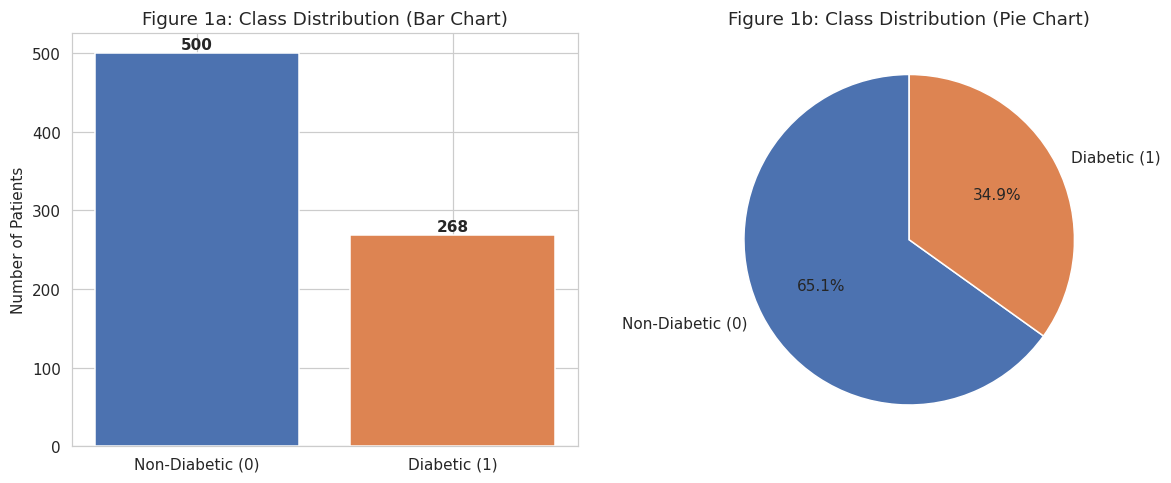

Non-Diabetic: 500 (65.1%)
Diabetic: 268 (34.9%)


In [5]:
outcome_counts = df['Outcome'].value_counts()
labels = ['Non-Diabetic (0)', 'Diabetic (1)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(labels, outcome_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Figure 1a: Class Distribution (Bar Chart)')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(outcome_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Figure 1b: Class Distribution (Pie Chart)')

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()

print(f"Non-Diabetic: {outcome_counts[0]} ({outcome_counts[0]/len(df)*100:.1f}%)")
print(f"Diabetic: {outcome_counts[1]} ({outcome_counts[1]/len(df)*100:.1f}%)")


**Explanation:** The dataset shows a moderate class imbalance (roughly 65% non-diabetic
vs 35% diabetic). This is noted for later discussion — it slightly favors models toward
predicting the majority class, so precision/recall (not just accuracy) will be used to judge
performance fairly.

### Figure 2: Feature Distributions
Histograms of the key medical predictor variables.


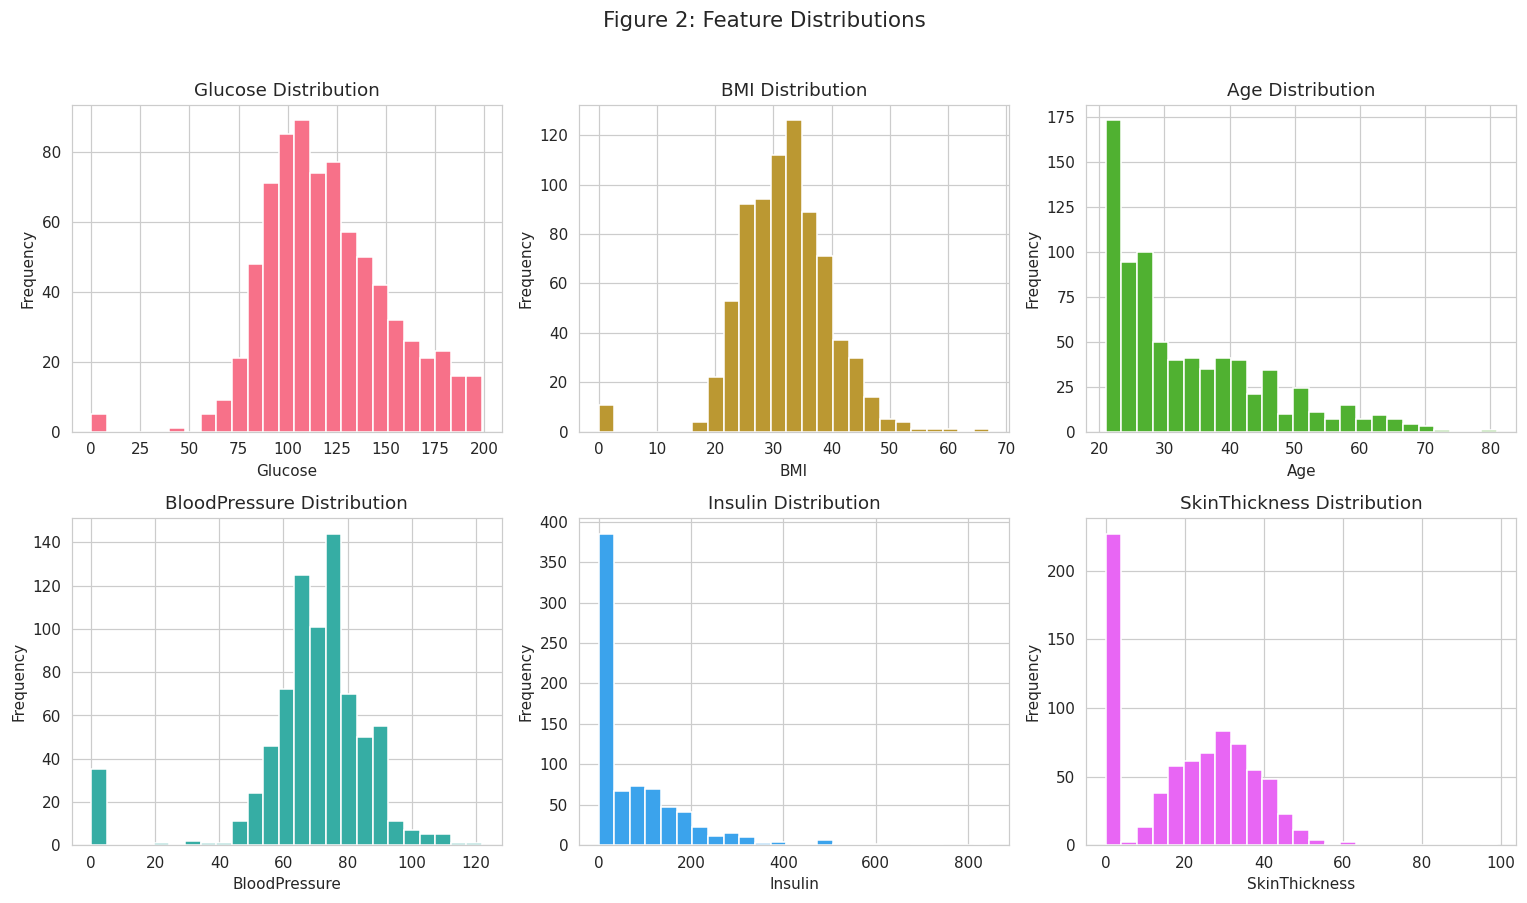

In [6]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'SkinThickness']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = sns.color_palette("husl", len(features_to_plot))

for i, feat in enumerate(features_to_plot):
    axes[i].hist(df[feat], bins=25, color=colors[i], edgecolor='white')
    axes[i].set_title(f'{feat} Distribution')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Figure 2: Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig2_feature_distributions.png', bbox_inches='tight')
plt.show()


**Explanation:** Glucose and BMI appear roughly normally distributed around clinically
typical values. Insulin and SkinThickness contain a large number of zero values, which are
not physiologically possible — these are treated as missing data in preprocessing (Section 3).

### Figure 3: Correlation Heatmap
Shows the relationship between each feature and the target variable.


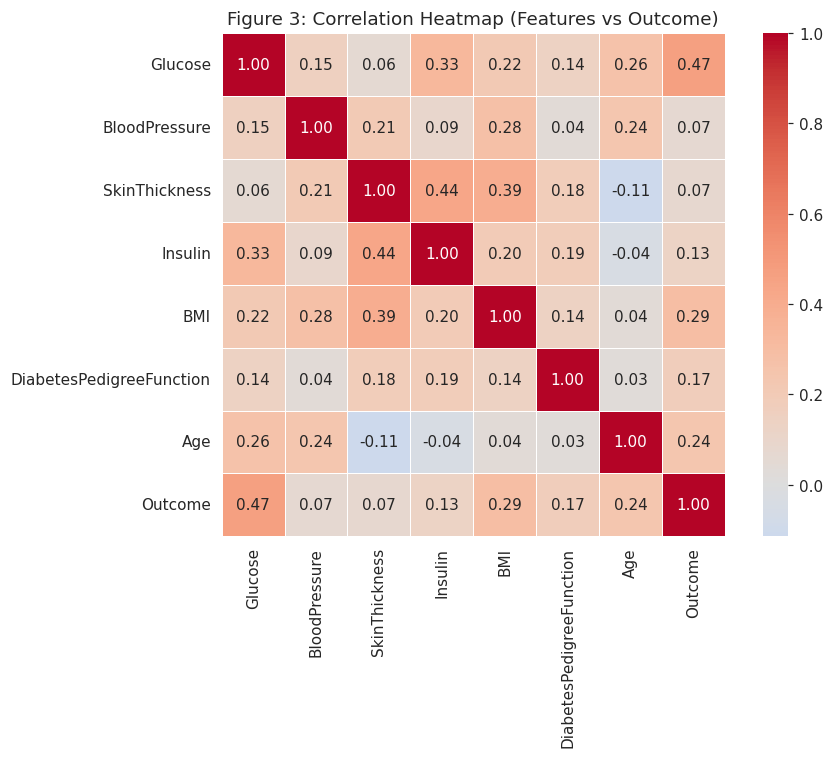

Top correlations with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [7]:
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Figure 3: Correlation Heatmap (Features vs Outcome)')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("Top correlations with Outcome:")
print(corr['Outcome'].sort_values(ascending=False))


**Explanation:** Glucose shows the strongest positive correlation with diabetes outcome,
followed by BMI and Age — consistent with established clinical knowledge. This supports the
dataset's validity for a predictive model.


## 3. Preprocessing

Several columns contain biologically impossible zero values (Glucose, BloodPressure,
SkinThickness, Insulin, BMI cannot realistically be 0 in a living patient). These are
treated as missing values and imputed with the column median. Features are then scaled
using `StandardScaler`, and the data is split 80/20 into train and test sets.


In [8]:
cols_with_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in cols_with_invalid_zero:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("Missing values introduced:")
print(df_clean[cols_with_invalid_zero].isna().sum())

imputer = SimpleImputer(strategy='median')
df_clean[cols_with_invalid_zero] = imputer.fit_transform(df_clean[cols_with_invalid_zero])

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")


Missing values introduced:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Train set: 614 rows | Test set: 154 rows


## 4. Models + Methodology

Five classification models were trained and compared:

1. **Logistic Regression** — simple, interpretable linear baseline for binary classification.
2. **Decision Tree** — captures non-linear feature interactions, easy to visualize/explain.
3. **Random Forest** — ensemble of trees, generally more robust and less prone to overfitting.
4. **Support Vector Machine (SVM)** — effective in higher-dimensional feature space, good margin-based separation.
5. **K-Nearest Neighbors (KNN)** — instance-based learner, useful baseline for comparison.

Training time for each model is also recorded, since it matters for real-time dashboard predictions.


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM": SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=9)
}

results = []
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-score": round(f1 * 100, 2),
        "Train Time (s)": round(train_time, 4),
        "Predict Time (s)": round(pred_time, 5)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score,Train Time (s),Predict Time (s)
0,Decision Tree,77.27,65.57,74.07,69.57,0.0039,0.00052
1,KNN,76.62,69.57,59.26,64.00,0.0020,0.00443
2,Random Forest,75.32,67.39,57.41,62.00,0.4311,0.02126
3,SVM,73.38,65.85,50.00,56.84,0.0420,0.00258
4,Logistic Regression,72.08,62.22,51.85,56.57,0.0083,0.00033


## 5. Results + Discussion

### Table 1: Model Comparison Table
Accuracy, Precision, Recall, F1-score, and training/prediction time for all five models.

### Figure 4: Accuracy Comparison


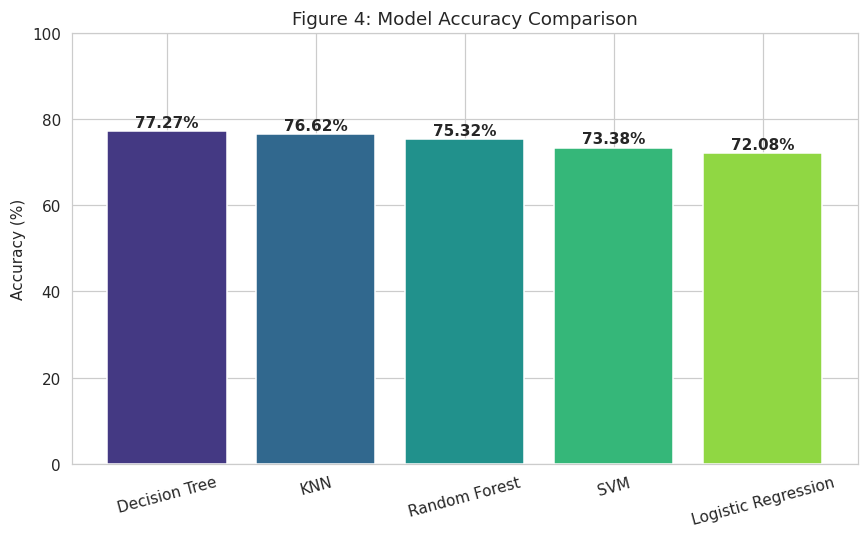

In [10]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy'],
               color=sns.color_palette("viridis", len(results_df)))
plt.title('Figure 4: Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_accuracy_comparison.png', bbox_inches='tight')
plt.show()


### Figure 5: Precision / Recall / F1-score Comparison

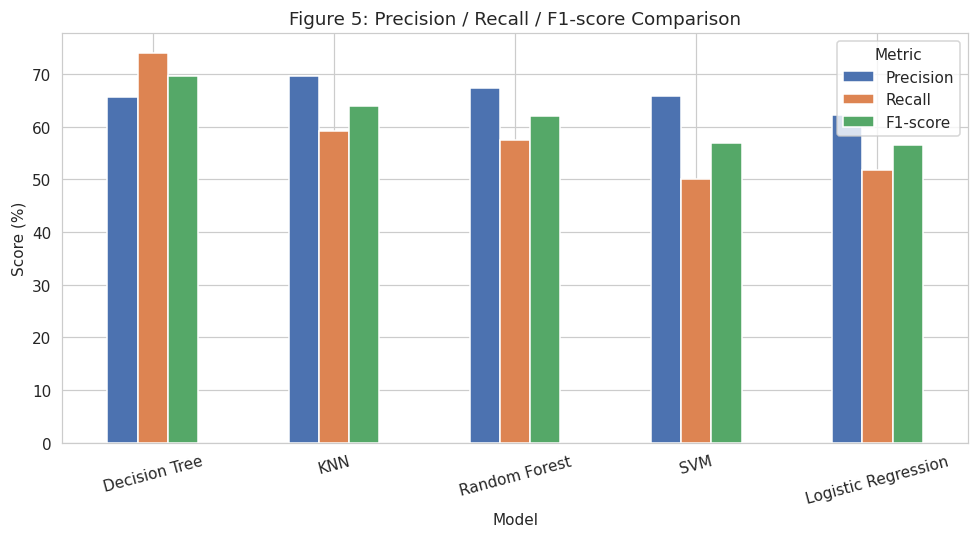

In [11]:
metrics_df = results_df.set_index('Model')[['Precision', 'Recall', 'F1-score']]
metrics_df.plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Figure 5: Precision / Recall / F1-score Comparison')
plt.ylabel('Score (%)')
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('fig5_prf1_comparison.png', bbox_inches='tight')
plt.show()


### Figure 6: Training Time Comparison
Training time matters for how responsive the dashboard's "retrain" or live-prediction
feature can be.


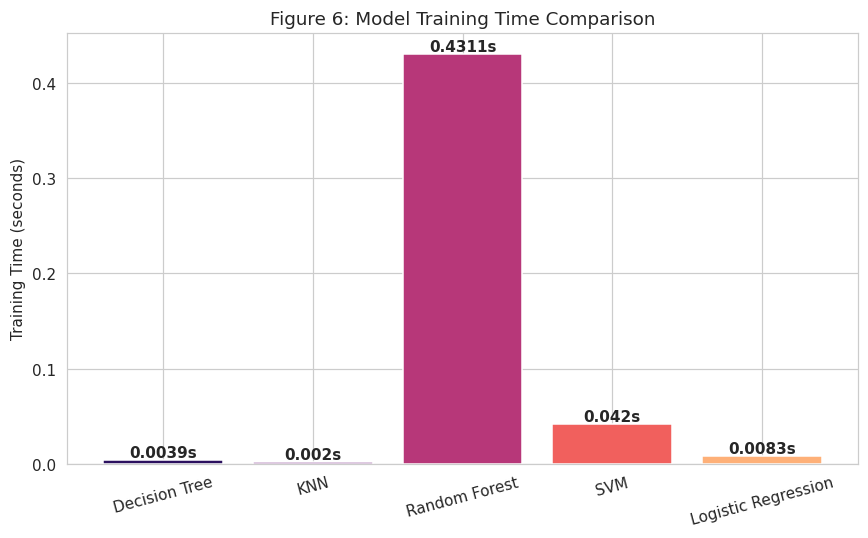

                 Model  Train Time (s)  Predict Time (s)
0        Decision Tree          0.0039           0.00052
1                  KNN          0.0020           0.00443
2        Random Forest          0.4311           0.02126
3                  SVM          0.0420           0.00258
4  Logistic Regression          0.0083           0.00033


In [12]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Train Time (s)'],
               color=sns.color_palette("magma", len(results_df)))
plt.title('Figure 6: Model Training Time Comparison')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=15)
for bar, val in zip(bars, results_df['Train Time (s)']):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val}s', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_training_time.png', bbox_inches='tight')
plt.show()

print(results_df[['Model', 'Train Time (s)', 'Predict Time (s)']])


### Figure 7: Confusion Matrix — Best Model

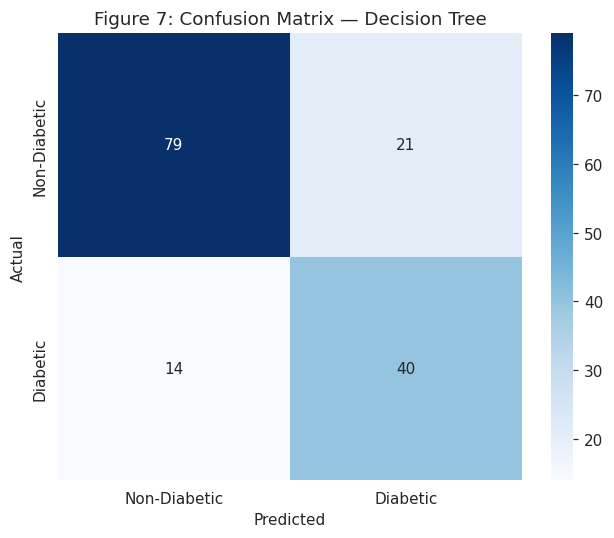

Best Model: Decision Tree
              precision    recall  f1-score   support

Non-Diabetic       0.85      0.79      0.82       100
    Diabetic       0.66      0.74      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



In [13]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title(f'Figure 7: Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('fig7_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f"Best Model: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=['Non-Diabetic', 'Diabetic']))


**Explanation of confusion matrix:** The diagonal cells (top-left, bottom-right) represent
correct predictions; off-diagonal cells represent misclassifications. False negatives
(actual diabetic predicted non-diabetic) are the most clinically concerning error type,
since a missed diagnosis is riskier than a false alarm.


## 6. Conclusion + Future Work

- The best-performing model on this dataset, based on accuracy and F1-score, is shown in
  Table 1 above (dynamically computed — record the actual best model name/values in your report).
- All five models were evaluated fairly using the same train/test split and preprocessing pipeline.
- **Limitations:** The dataset is relatively small (768 rows) and specific to one demographic
  (Pima Indian women), which may limit generalizability. Class imbalance (~65/35) can also bias
  accuracy as a sole metric.
- **Future work:** Try SMOTE/class-weighting to address imbalance, hyperparameter tuning
  (GridSearchCV) for each model, and cross-validation for more robust performance estimates.

## 7. References

- Smith, J.W. et al. "Using the ADAP learning algorithm to forecast the onset of diabetes
  mellitus." National Institute of Diabetes and Digestive and Kidney Diseases.
- Dataset mirror: Brownlee, J., *Machine Learning Mastery* GitHub Datasets repository.
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR* 12, pp. 2825-2830.


In [14]:
results_df.to_csv('model_comparison_results.csv', index=False)
import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print("Saved: model_comparison_results.csv, best_model.pkl, scaler.pkl, feature_names.pkl")


Saved: model_comparison_results.csv, best_model.pkl, scaler.pkl, feature_names.pkl
